# CogniLearn — Phase 2: Model Training & AI Layer

This notebook implements all five AI sub-systems defined in PLAN.md Phase 2:

| Section | System | Output |
|---|---|---|
| 2.1 | Error Type Classifier (XGBoost + SHAP) | `models/error_classifier.pkl` |
| 2.2 | Personalised Forgetting Curve (Ebbinghaus) | fitted `S` constants per student-topic |
| 2.3 | EAR Fatigue Detector (MediaPipe) | formula implementation, no training required |
| 2.4 | RAG Pipeline (Azure OpenAI + pgvector) | embedding seed script + retrieval demo |
| 2.5 | Study Brief Optimizer | greedy priority schedule |

**Data sources:** `GeneratedData/sample_interactions.json` · `GeneratedData/curriculum_notes.json`

## 0 · Setup & Imports

In [1]:
import json
import os
import math
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

warnings.filterwarnings('ignore')

DATA_DIR   = Path('GeneratedData')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

print('Data dir    :', DATA_DIR.resolve())
print('Models dir  :', MODELS_DIR.resolve())

Data dir    : C:\Users\jacob\Documents\GitHub\build-an-react-interface-3-frontend-web-interface-must-include-this-is-what-judges-see\Model\GeneratedData
Models dir  : C:\Users\jacob\Documents\GitHub\build-an-react-interface-3-frontend-web-interface-must-include-this-is-what-judges-see\Model\models


In [2]:
# Load generated datasets
with open(DATA_DIR / 'sample_interactions.json', encoding='utf-8') as f:
    raw_interactions = json.load(f)

with open(DATA_DIR / 'curriculum_notes.json', encoding='utf-8') as f:
    curriculum_notes = json.load(f)

df = pd.DataFrame(raw_interactions)
df['session_timestamp'] = pd.to_datetime(df['session_timestamp'], utc=True)

print(f'Interactions : {len(df):,} rows')
print(f'Students     : {df["student_id"].nunique()}')
print(f'Topics       : {df["topic"].nunique()}')
print(f'Error labels : {sorted(df["error_label"].unique())}')
print(f'\nSample:\n{df.head(3).to_string()}')

Interactions : 1,519 rows
Students     : 25
Topics       : 25
Error labels : ['anxiety', 'careless', 'decay', 'knowledge_gap', 'misconception', 'transfer_failure']

Sample:
  student_id               topic question_id  is_correct  time_taken_seconds  attempt_number  timed_condition         session_timestamp  days_since_last_correct                            cross_topic_ids    error_label
0    stu_019      diffeq-systems      q_1149        True                  47               5            False 2026-02-23 13:00:00+00:00                        1  [diffeq-second-order, linalg-eigenvalues]        anxiety
1    stu_013         prob-basics      q_0728        True                  42               1             True 2026-02-21 12:30:00+00:00                       10                                         []  misconception
2    stu_008  diffeq-first-order      q_0414        True                  56               2            False 2026-02-11 10:30:00+00:00                       10          

---
## 2.1 · Error Type Classifier

**Goal:** Given a per-student-per-topic feature vector, predict the error type  
**Model:** XGBoost multi-class (6 classes)  
**Output:** `models/error_classifier.pkl` + SHAP TreeExplainer

### 2.1.1 Feature Engineering — aggregate to student×topic level

In [3]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate raw interaction rows into one feature vector per student-topic."""
    records = []

    for (student_id, topic), grp in df.groupby(['student_id', 'topic']):
        grp = grp.sort_values('session_timestamp')
        n_total   = len(grp)
        n_correct = grp['is_correct'].sum()

        accuracy = n_correct / n_total if n_total > 0 else 0.0

        # Rolling 5-attempt accuracy std
        rolling_acc = grp['is_correct'].rolling(5, min_periods=2).mean()
        accuracy_variance = float(rolling_acc.std()) if not rolling_acc.isna().all() else 0.0

        # Mean time on correct vs wrong answers
        correct_times = grp.loc[grp['is_correct'],  'time_taken_seconds']
        wrong_times   = grp.loc[~grp['is_correct'], 'time_taken_seconds']
        avg_time_correct = float(correct_times.mean()) if len(correct_times) > 0 else 0.0
        avg_time_wrong   = float(wrong_times.mean())   if len(wrong_times)   > 0 else 0.0

        # Timed-accuracy delta: accuracy_untimed − accuracy_timed
        timed   = grp[grp['timed_condition'] == True]
        untimed = grp[grp['timed_condition'] == False]
        acc_timed   = timed['is_correct'].mean()   if len(timed)   > 0 else accuracy
        acc_untimed = untimed['is_correct'].mean() if len(untimed) > 0 else accuracy
        timed_accuracy_delta = float(acc_untimed - acc_timed)

        days_since_last_correct = float(grp['days_since_last_correct'].iloc[-1])

        # Cross-topic error rate: fraction of rows whose cross_topic_ids are non-empty AND wrong
        has_cross = grp['cross_topic_ids'].apply(lambda x: len(x) > 0 if isinstance(x, list) else False)
        cross_subset = grp[has_cross]
        cross_topic_error_rate = float((~cross_subset['is_correct']).mean()) if len(cross_subset) > 0 else 0.0

        # Ground-truth label: majority vote across the group
        label = grp['error_label'].mode()[0]

        records.append({
            'student_id'            : student_id,
            'topic'                 : topic,
            'accuracy'              : accuracy,
            'accuracy_variance'     : accuracy_variance,
            'avg_time_correct'      : avg_time_correct,
            'avg_time_wrong'        : avg_time_wrong,
            'timed_accuracy_delta'  : timed_accuracy_delta,
            'days_since_last_correct': days_since_last_correct,
            'cross_topic_error_rate': cross_topic_error_rate,
            'error_label'           : label,
        })

    return pd.DataFrame(records)


features_df = build_features(df)
print(f'Feature matrix: {features_df.shape}')
print(f'Label distribution:\n{features_df["error_label"].value_counts()}')
features_df.head()

Feature matrix: (250, 10)
Label distribution:
error_label
decay               46
anxiety             46
transfer_failure    46
careless            44
misconception       39
knowledge_gap       29
Name: count, dtype: int64


,student_id,topic,accuracy,accuracy_variance,avg_time_correct,avg_time_wrong,timed_accuracy_delta,days_since_last_correct,cross_topic_error_rate,error_label
0,stu_001,calc-limits,0.000000,0.000000,0.0,68.625000,0.0,3.0,0.000000,knowledge_gap
1,stu_001,calc-taylor-series,0.000000,0.000000,0.0,88.250000,0.0,5.0,1.000000,knowledge_gap
2,stu_001,calc-techniques,0.285714,0.157204,31.0,12.600000,-0.5,1.0,0.714286,misconception
3,stu_001,diffeq-first-order,0.500000,0.096225,6.0,12.000000,0.0,1.0,0.500000,careless
4,stu_001,diffeq-systems,0.142857,0.109756,31.0,12.833333,-0.2,8.0,0.857143,misconception


### 2.1.2 Train / Evaluate XGBoost Classifier

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import joblib

FEATURE_COLS = [
    'accuracy', 'accuracy_variance', 'avg_time_correct',
    'avg_time_wrong', 'timed_accuracy_delta',
    'days_since_last_correct', 'cross_topic_error_rate',
]

X = features_df[FEATURE_COLS].values
le = LabelEncoder()
y = le.fit_transform(features_df['error_label'])

print('Classes:', le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {len(X_train)}  Test: {len(X_test)}')

clf = XGBClassifier(
    n_estimators   = 200,
    max_depth      = 4,
    learning_rate  = 0.1,
    objective      = 'multi:softmax',
    num_class      = len(le.classes_),
    eval_metric    = 'mlogloss',
    use_label_encoder = False,
    random_state   = 42,
    n_jobs         = -1,
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

y_pred = clf.predict(X_test)
print(f'\nOverall accuracy: {accuracy_score(y_test, y_pred):.3f}')
print('\nPer-class F1:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classes: ['anxiety' 'careless' 'decay' 'knowledge_gap' 'misconception'
 'transfer_failure']
Train: 200  Test: 50

Overall accuracy: 0.840

Per-class F1:
                  precision    recall  f1-score   support

         anxiety       0.75      0.67      0.71         9
        careless       1.00      1.00      1.00         9
           decay       1.00      1.00      1.00         9
   knowledge_gap       0.80      0.67      0.73         6
   misconception       0.89      1.00      0.94         8
transfer_failure       0.60      0.67      0.63         9

        accuracy                           0.84        50
       macro avg       0.84      0.83      0.83        50
    weighted avg       0.84      0.84      0.84        50



### 2.1.3 SHAP Explanations

SHAP values shape: (50, 7, 6)


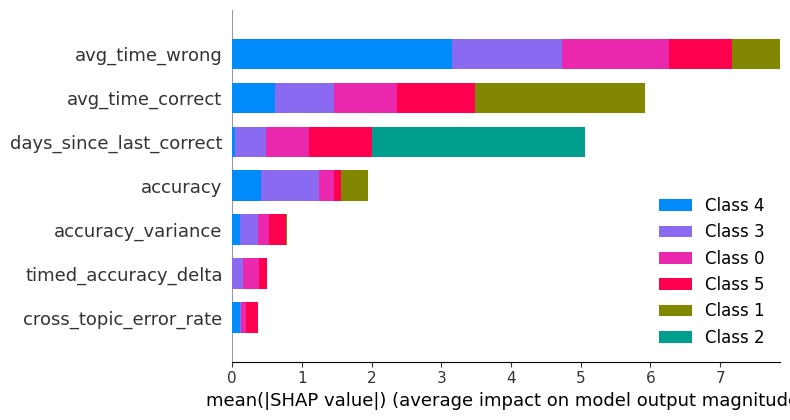


Sample inference output:
{
  "error_type": "knowledge_gap",
  "shap_values": [
    {
      "feature": "avg_time_wrong",
      "impact": 1.1808,
      "direction": "positive"
    },
    {
      "feature": "accuracy",
      "impact": 0.9084,
      "direction": "positive"
    },
    {
      "feature": "avg_time_correct",
      "impact": 0.7712,
      "direction": "negative"
    },
    {
      "feature": "days_since_last_correct",
      "impact": 0.7255,
      "direction": "positive"
    },
    {
      "feature": "accuracy_variance",
      "impact": 0.5799,
      "direction": "positive"
    },
    {
      "feature": "timed_accuracy_delta",
      "impact": 0.2904,
      "direction": "positive"
    },
    {
      "feature": "cross_topic_error_rate",
      "impact": 0.046,
      "direction": "positive"
    }
  ]
}


In [6]:
import shap

explainer = shap.TreeExplainer(clf)
shap_values_test = explainer.shap_values(X_test)

# shap_values_test shape: (n_samples, n_features) for multi:softmax
print('SHAP values shape:', np.array(shap_values_test).shape)

# Summary bar plot — mean absolute SHAP across all classes
shap.summary_plot(
    shap_values_test,
    features=X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=True,
)


def predict_with_shap(student_features: dict) -> dict:
    """
    Inference helper — returns the output shape expected by the frontend:
    { error_type, shap_values: [{ feature, impact, direction }] }

    Handles all three SHAP output shapes across library versions:
      - list of (n_samples, n_features)  → old API, one array per class
      - ndarray (n_samples, n_features, n_classes) → new API 3-D
      - ndarray (n_samples, n_features)  → binary / already sliced
    """
    x = np.array([[student_features[c] for c in FEATURE_COLS]])
    pred_class = int(clf.predict(x)[0])
    error_type = le.classes_[pred_class]

    sv = explainer.shap_values(x)

    if isinstance(sv, list):
        # Old SHAP API: list[n_classes] of (n_samples, n_features)
        sv_1d = np.array(sv[pred_class])[0]
    else:
        sv = np.array(sv)
        if sv.ndim == 3:
            # New SHAP API: (n_samples, n_features, n_classes)
            sv_1d = sv[0, :, pred_class]
        else:
            # Binary or already reduced: (n_samples, n_features)
            sv_1d = sv[0]

    shap_output = []
    for feat, val in sorted(zip(FEATURE_COLS, sv_1d),
                            key=lambda pair: abs(float(pair[1])), reverse=True):
        shap_output.append({
            'feature'  : feat,
            'impact'   : round(abs(float(val)), 4),
            'direction': 'positive' if float(val) >= 0 else 'negative',
        })

    return {'error_type': error_type, 'shap_values': shap_output}


# Demo: predict for the first test sample
demo = {c: float(X_test[0][i]) for i, c in enumerate(FEATURE_COLS)}
result = predict_with_shap(demo)
print('\nSample inference output:')
print(json.dumps(result, indent=2))

### 2.1.4 Save Model Artifacts

In [7]:
joblib.dump(clf,      MODELS_DIR / 'error_classifier.pkl')
joblib.dump(le,       MODELS_DIR / 'label_encoder.pkl')
joblib.dump(explainer, MODELS_DIR / 'shap_explainer.pkl')

meta = {'feature_cols': FEATURE_COLS, 'classes': list(le.classes_)}
with open(MODELS_DIR / 'classifier_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
for p in sorted(MODELS_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size:,} bytes)')

Saved:
  classifier_meta.json  (349 bytes)
  error_classifier.pkl  (1,045,955 bytes)
  label_encoder.pkl  (553 bytes)
  shap_explainer.pkl  (3,792,971 bytes)


---
## 2.2 · Personalised Forgetting Curve

**Model:** Ebbinghaus exponential decay — `R(t) = e^(−t / S)`  
Fit the stability constant `S` per student-topic using `scipy.optimize.curve_fit`.  
**Output:** DataFrame of `(student_id, topic_id, stability_S, last_correct_at, risk_score)` → ready for Supabase `topic_stability` table.

In [8]:
from scipy.optimize import curve_fit
from datetime import timezone

REFERENCE_DATE = pd.Timestamp('2026-03-01', tz='UTC')


def ebbinghaus(t: np.ndarray, S: float) -> np.ndarray:
    """Retention R(t) = exp(-t / S); S is the stability constant in days."""
    return np.exp(-t / S)


def fit_forgetting_curve(grp: pd.DataFrame) -> dict:
    """
    Given a group of interactions for one student-topic:
    1. Build a (days_elapsed, is_correct) time series.
    2. Fit S via least-squares.
    3. Compute current risk = 1 − R(days_since_last_correct).
    """
    grp = grp.sort_values('session_timestamp')
    first_correct = grp.loc[grp['is_correct'], 'session_timestamp'].min()
    if pd.isna(first_correct):
        return None  # never answered correctly — skip

    # Days since first correct answer for each row
    grp = grp[grp['session_timestamp'] >= first_correct].copy()
    grp['t'] = (grp['session_timestamp'] - first_correct).dt.total_seconds() / 86400
    grp['retention'] = grp['is_correct'].astype(float)

    t_vals = grp['t'].values
    r_vals = grp['retention'].values

    S_fitted = 7.0  # default fallback (one-week half-life)
    if len(t_vals) >= 3 and r_vals.std() > 0:
        try:
            popt, _ = curve_fit(ebbinghaus, t_vals, r_vals, p0=[7.0], bounds=(0.1, 365))
            S_fitted = float(popt[0])
        except RuntimeError:
            pass  # convergence failure → keep default

    # Last correct timestamp
    last_correct_at = grp.loc[grp['is_correct'], 'session_timestamp'].max()
    days_elapsed    = (REFERENCE_DATE - last_correct_at).total_seconds() / 86400
    risk_score      = float(1 - ebbinghaus(max(0, days_elapsed), S_fitted))

    decay_label = 'fast' if S_fitted < 5 else ('moderate' if S_fitted <= 14 else 'slow')

    return {
        'stability_S'     : round(S_fitted, 4),
        'last_correct_at' : last_correct_at.isoformat(),
        'days_elapsed'    : round(days_elapsed, 2),
        'risk_score'      : round(risk_score, 4),
        'decay_label'     : decay_label,
    }


stability_records = []
for (student_id, topic_id), grp in df.groupby(['student_id', 'topic']):
    result = fit_forgetting_curve(grp)
    if result:
        stability_records.append({'student_id': student_id, 'topic_id': topic_id, **result})

stability_df = pd.DataFrame(stability_records)
print(f'Fitted curves: {len(stability_df)}')
print(stability_df.describe())
stability_df.head()

Fitted curves: 227
       stability_S  days_elapsed  risk_score
count   227.000000    227.000000  227.000000
mean     33.251586     19.680749    0.638269
std      58.633810     13.737149    0.354884
min       0.100000      3.140000    0.014900
25%       4.484300      8.465000    0.282050
50%      10.438100     15.360000    0.747700
75%      38.448950     29.435000    0.999500
max     365.000000     57.620000    1.000000


,student_id,topic_id,stability_S,last_correct_at,days_elapsed,risk_score,decay_label
0,stu_001,calc-techniques,18.0597,2026-02-04T08:30:00+00:00,24.65,0.7445,slow
1,stu_001,diffeq-first-order,52.4597,2026-02-25T14:00:00+00:00,3.42,0.0631,slow
2,stu_001,diffeq-systems,0.4383,2026-01-28T17:00:00+00:00,31.29,1.0000,fast
3,stu_001,linalg-linear-systems,0.6737,2026-02-04T20:15:00+00:00,24.16,1.0000,fast
4,stu_001,linalg-matrices,7.0000,2026-02-21T21:00:00+00:00,7.12,0.6386,moderate


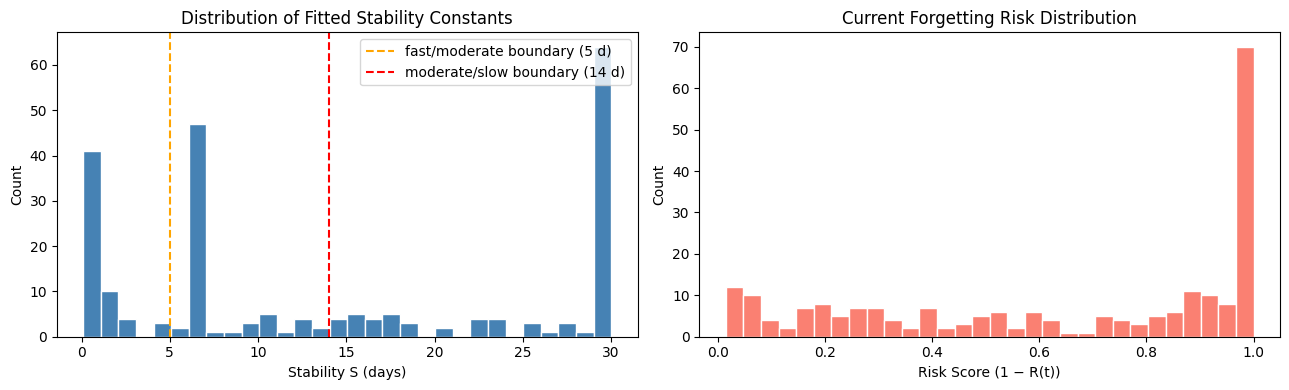

Plot saved.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of S values
axes[0].hist(stability_df['stability_S'].clip(upper=30), bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(5,  color='orange', linestyle='--', label='fast/moderate boundary (5 d)')
axes[0].axvline(14, color='red',    linestyle='--', label='moderate/slow boundary (14 d)')
axes[0].set_xlabel('Stability S (days)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Fitted Stability Constants')
axes[0].legend()

# Current risk score distribution
axes[1].hist(stability_df['risk_score'], bins=30, color='salmon', edgecolor='white')
axes[1].set_xlabel('Risk Score (1 − R(t))')
axes[1].set_ylabel('Count')
axes[1].set_title('Current Forgetting Risk Distribution')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'forgetting_curve_analysis.png', dpi=120)
plt.show()
print('Plot saved.')

In [10]:
# Build the riskTopics output shape expected by the frontend (StudyBrief page)
TOPIC_TITLES = {note['topic_id']: note['title'] for note in curriculum_notes}

def compute_next_review(risk: float) -> str:
    if risk >= 0.75: return 'Today'
    if risk >= 0.50: return 'Tomorrow'
    if risk >= 0.25: return 'This week'
    return 'Next week'


# Example: top 5 highest-risk topics for student stu_001
sample_student = stability_df['student_id'].iloc[0]
student_risks  = stability_df[stability_df['student_id'] == sample_student].copy()
student_risks  = student_risks.sort_values('risk_score', ascending=False).head(5)

risk_topics_output = [
    {
        'topic'      : TOPIC_TITLES.get(row['topic_id'], row['topic_id']),
        'risk'       : row['risk_score'],
        'decay'      : row['decay_label'],
        'nextReview' : compute_next_review(row['risk_score']),
    }
    for _, row in student_risks.iterrows()
]

print(f'riskTopics output for {sample_student}:')
print(json.dumps(risk_topics_output, indent=2))

stability_df.to_csv(MODELS_DIR / 'topic_stability.csv', index=False)
print('\nStability table saved to models/topic_stability.csv')

riskTopics output for stu_001:
[
  {
    "topic": "Systems of Linear Equations",
    "risk": 1.0,
    "decay": "fast",
    "nextReview": "Today"
  },
  {
    "topic": "Systems of Differential Equations",
    "risk": 1.0,
    "decay": "fast",
    "nextReview": "Today"
  },
  {
    "topic": "Integration Techniques",
    "risk": 0.7445,
    "decay": "slow",
    "nextReview": "Tomorrow"
  },
  {
    "topic": "Matrix Operations",
    "risk": 0.6386,
    "decay": "moderate",
    "nextReview": "Tomorrow"
  },
  {
    "topic": "Hypothesis Testing",
    "risk": 0.5931,
    "decay": "slow",
    "nextReview": "Tomorrow"
  }
]

Stability table saved to models/topic_stability.csv


---
## 2.3 · EAR Fatigue Detector

No model training is required — MediaPipe Face Mesh ships pre-trained 468-landmark weights.  
This section implements and unit-tests the EAR calculation + state classifier that will run inside `server/ai/ear_processor.py`.

**Formula (Soukupová & Čech, 2016):**
```
EAR = ( ||p2−p6|| + ||p3−p5|| ) / ( 2 × ||p1−p4|| )
```
Left eye landmarks  : `[362, 385, 387, 263, 373, 380]`  
Right eye landmarks : `[33, 160, 158, 133, 153, 144]`

In [11]:
from collections import deque

# --- Pure-Python EAR implementation (mirrors ear_processor.py) ---

LEFT_EYE_IDX  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE_IDX = [33, 160, 158, 133, 153, 144]

EAR_FOCUSED  = 0.25
EAR_ENGAGED  = 0.21
WINDOW_SIZE  = 30


def euclidean(p1: np.ndarray, p2: np.ndarray) -> float:
    return float(np.linalg.norm(p1 - p2))


def compute_ear(landmarks: np.ndarray, idx: list) -> float:
    """
    landmarks : (N, 2) or (N, 3) array of (x, y[, z]) face mesh points
    idx       : 6 landmark indices [p1, p2, p3, p4, p5, p6]
    """
    p1, p2, p3, p4, p5, p6 = [landmarks[i, :2] for i in idx]
    vertical   = euclidean(p2, p6) + euclidean(p3, p5)
    horizontal = 2 * euclidean(p1, p4)
    return vertical / horizontal if horizontal > 0 else 0.0


def classify_state(ear: float) -> str:
    if ear > EAR_FOCUSED:
        return 'focused'
    if ear > EAR_ENGAGED:
        return 'engaged'
    return 'drowsy'


class FatigueTracker:
    """Rolling 30-frame weighted fatigue score, clamped 0–100."""

    def __init__(self, window: int = WINDOW_SIZE):
        self._history = deque(maxlen=window)

    def update(self, ear: float) -> float:
        deficit = max(0.0, EAR_FOCUSED - ear) * 400
        self._history.append(deficit)
        return min(100.0, float(np.mean(self._history)))


# ----- Unit tests with synthetic landmark arrays -----
rng = np.random.default_rng(0)

def make_eye_landmarks(ear_target: float, idx: list) -> np.ndarray:
    """Return a 468-point mesh where the eye specified by idx yields ~ear_target."""
    lm = rng.random((468, 2))
    # Force the 6 eye points so that EAR ≈ ear_target
    # p1 and p4 are the horizontal corners
    p1 = np.array([0.0, 0.5])
    p4 = np.array([1.0, 0.5])
    half_v = ear_target  # vertical sum = 2 * ear_target * ||p1-p4|| / 2
    p2 = np.array([0.33, 0.5 + half_v / 2])
    p6 = np.array([0.33, 0.5 - half_v / 2])
    p3 = np.array([0.66, 0.5 + half_v / 2])
    p5 = np.array([0.66, 0.5 - half_v / 2])
    for i, pt in zip(idx, [p1, p2, p3, p4, p5, p6]):
        lm[i] = pt
    return lm


tracker = FatigueTracker()
print('EAR  | State     | Fatigue')
print('-----|-----------|--------')
for target_ear in [0.30, 0.27, 0.24, 0.22, 0.18, 0.15, 0.12]:
    lm   = make_eye_landmarks(target_ear, LEFT_EYE_IDX)
    ear  = (compute_ear(lm, LEFT_EYE_IDX) + compute_ear(lm, RIGHT_EYE_IDX)) / 2
    # For the right eye we just mirror the same test landmarks
    lm2  = make_eye_landmarks(target_ear, RIGHT_EYE_IDX)
    ear  = (compute_ear(lm, LEFT_EYE_IDX) + compute_ear(lm2, RIGHT_EYE_IDX)) / 2
    state   = classify_state(ear)
    fatigue = tracker.update(ear)
    print(f'{ear:.3f} | {state:<9} | {fatigue:.1f}')

EAR  | State     | Fatigue
-----|-----------|--------
0.300 | focused   | 0.0
0.270 | focused   | 0.0
0.240 | engaged   | 1.3
0.220 | engaged   | 4.0
0.180 | drowsy    | 8.8
0.150 | drowsy    | 14.0
0.120 | drowsy    | 19.4


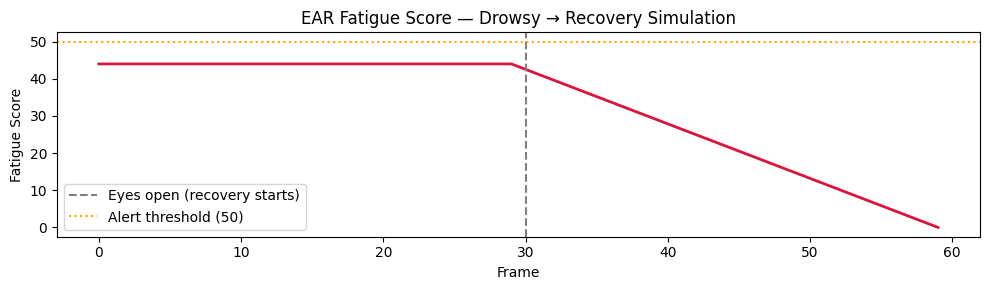

POST /attention/frame → response shape:
{
  "ear": 0.23,
  "state": "engaged",
  "fatigue_score": 0.3
}


In [12]:
# Simulate 30 drowsy frames → 30 awake frames to show recovery
tracker2 = FatigueTracker()
fatigue_trace = []

for ear in ([0.14] * 30) + ([0.30] * 30):
    fatigue_trace.append(tracker2.update(ear))

plt.figure(figsize=(10, 3))
plt.plot(fatigue_trace, color='crimson', linewidth=2)
plt.axvline(30, linestyle='--', color='gray', label='Eyes open (recovery starts)')
plt.axhline(50, linestyle=':', color='orange', label='Alert threshold (50)')
plt.xlabel('Frame')
plt.ylabel('Fatigue Score')
plt.title('EAR Fatigue Score — Drowsy → Recovery Simulation')
plt.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / 'ear_fatigue_simulation.png', dpi=120)
plt.show()

# Print the inference payload shape the backend returns
sample_payload = {
    'ear'          : 0.23,
    'state'        : classify_state(0.23),
    'fatigue_score': round(tracker2.update(0.23), 1),
}
print('POST /attention/frame → response shape:')
print(json.dumps(sample_payload, indent=2))

---
## 2.4 · RAG Pipeline — TeachMe Voice

Two modes:
- **Offline demo** (no keys needed) — TF-IDF cosine similarity over `curriculum_notes.json` to validate retrieval quality  
- **Production path** — Azure `text-embedding-3-small` + Supabase `pgvector` (requires `.env` credentials)  

**Output shape** matches `extractedKeywords` + `ragExplanation` mock data from the frontend.

### 2.4.1 Offline TF-IDF Retrieval Demo

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

corpus_ids   = [n['topic_id'] for n in curriculum_notes]
corpus_texts = [n['title'] + ' ' + n['content'] for n in curriculum_notes]

tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
C_mat = tfidf.fit_transform(corpus_texts)


def tfidf_retrieve(query: str, top_k: int = 3) -> list:
    q_vec = tfidf.transform([query])
    sims  = cosine_similarity(q_vec, C_mat)[0]
    top   = sims.argsort()[::-1][:top_k]
    return [
        {
            'topic_id' : corpus_ids[i],
            'title'    : curriculum_notes[i]['title'],
            'score'    : round(float(sims[i]), 4),
            'snippet'  : curriculum_notes[i]['content'][:200] + '…',
        }
        for i in top
    ]


DEMO_QUERIES = [
    'how do I integrate e^x times x',
    'explain eigenvalues step by step',
    'bayes theorem medical test example',
    'solve second order differential equations',
]

for q in DEMO_QUERIES:
    results = tfidf_retrieve(q)
    print(f'Query: "{q}"')
    for r in results:
        print(f'  [{r["score"]:.3f}] {r["title"]} ({r["topic_id"]})')
    print()

Query: "how do I integrate e^x times x"
  [0.129] Confidence Intervals (stats-confidence)
  [0.066] First-Order Differential Equations (diffeq-first-order)
  [0.000] Laplace Transforms (diffeq-laplace)

Query: "explain eigenvalues step by step"
  [0.137] Eigenvalues and Eigenvectors (linalg-eigenvalues)
  [0.135] Systems of Differential Equations (diffeq-systems)
  [0.093] Laplace Transforms (diffeq-laplace)

Query: "bayes theorem medical test example"
  [0.328] Bayes' Theorem (prob-bayes)
  [0.081] Hypothesis Testing (stats-hypothesis)
  [0.030] Integration by Parts (calc-integrals)

Query: "solve second order differential equations"
  [0.264] Second-Order Differential Equations (diffeq-second-order)
  [0.178] First-Order Differential Equations (diffeq-first-order)
  [0.074] Systems of Differential Equations (diffeq-systems)



### 2.4.2 Production Embedding Path (Azure OpenAI + pgvector)

The cell below is the **seed script** for the production pipeline.  
Set `RUN_EMBEDDING_SEED = True` and fill in the `.env` file before running.
This mirrors `server/ai/rag_pipeline.py --seed`.

In [14]:
RUN_EMBEDDING_SEED = False  # set True when Azure + Supabase credentials are available

if RUN_EMBEDDING_SEED:
    import os
    from openai import AzureOpenAI
    from supabase import create_client

    az_client  = AzureOpenAI(
        azure_endpoint = os.environ['AZURE_OPENAI_ENDPOINT'],
        api_key        = os.environ['AZURE_OPENAI_KEY'],
        api_version    = '2024-02-01',
    )
    supabase   = create_client(
        os.environ['SUPABASE_URL'],
        os.environ['SUPABASE_SERVICE_ROLE_KEY'],
    )
    EMBED_MODEL = os.environ.get('AZURE_EMBEDDING_DEPLOYMENT', 'text-embedding-3-small')

    rows = []
    for note in curriculum_notes:
        resp = az_client.embeddings.create(
            model = EMBED_MODEL,
            input = note['title'] + '\n' + note['content'],
        )
        embedding = resp.data[0].embedding  # list of 1536 floats
        rows.append({
            'topic_id' : note['topic_id'],
            'title'    : note['title'],
            'content'  : note['content'],
            'embedding': embedding,
        })
        print(f'Embedded: {note["topic_id"]}')

    supabase.table('curriculum_embeddings').upsert(rows, on_conflict='topic_id').execute()
    print(f'\nUpserted {len(rows)} embeddings into Supabase.')

else:
    print('Embedding seed skipped (RUN_EMBEDDING_SEED = False).')
    print('Set credentials in .env and flip the flag to seed production pgvector table.')

Embedding seed skipped (RUN_EMBEDDING_SEED = False).
Set credentials in .env and flip the flag to seed production pgvector table.


### 2.4.3 GPT-4o RAG Response Shape Demo

In [15]:
def mock_rag_response(query: str) -> dict:
    """
    Demonstrates the exact JSON shape POST /voice/process returns.
    In production this calls GPT-4o with the retrieved curriculum context.
    """
    retrieved = tfidf_retrieve(query, top_k=3)
    context   = '\n\n'.join(r['snippet'] for r in retrieved)

    # Simulated GPT-4o response (replace with real call in production)
    rag_explanation = (
        f"Based on your question about '{query}', here's a personalised explanation: "
        f"The most relevant concept is {retrieved[0]['title']}. "
        "[In production, GPT-4o generates a full paragraph using the retrieved context.]"
    )

    # Extract keywords from the query and top result titles
    all_words = query.lower().split() + retrieved[0]['title'].lower().split()
    keywords  = [
        {'word': w, 'relevance': round(1.0 / (i + 1), 2), 'isGap': i > 1}
        for i, w in enumerate(dict.fromkeys(all_words))  # deduplicate while preserving order
        if len(w) > 3
    ][:6]

    related_concepts = [r['topic_id'] for r in retrieved[1:]]

    return {
        'extractedKeywords' : keywords,
        'ragExplanation'    : rag_explanation,
        'relatedConcepts'   : related_concepts,
        'retrievedSources'  : [r['title'] for r in retrieved],
    }


demo_query  = 'how do I integrate e^x times x'
rag_output  = mock_rag_response(demo_query)
print('POST /voice/process → response shape:')
print(json.dumps(rag_output, indent=2))

POST /voice/process → response shape:
{
  "extractedKeywords": [
    {
      "word": "integrate",
      "relevance": 0.25,
      "isGap": true
    },
    {
      "word": "times",
      "relevance": 0.17,
      "isGap": true
    },
    {
      "word": "confidence",
      "relevance": 0.12,
      "isGap": true
    },
    {
      "word": "intervals",
      "relevance": 0.11,
      "isGap": true
    }
  ],
  "ragExplanation": "Based on your question about 'how do I integrate e^x times x', here's a personalised explanation: The most relevant concept is Confidence Intervals. [In production, GPT-4o generates a full paragraph using the retrieved context.]",
  "relatedConcepts": [
    "diffeq-first-order",
    "diffeq-laplace"
  ],
  "retrievedSources": [
    "Confidence Intervals",
    "First-Order Differential Equations",
    "Laplace Transforms"
  ]
}


---
## 2.5 · Study Brief Optimizer

**Algorithm:**
1. Score each topic: `priority = risk_score × decay_multiplier × exam_proximity_weight`
2. Sort by priority (descending)
3. Greedily pack 30–90 min blocks into daily windows
4. Insert Pomodoro breaks every 90 min
5. Tag block type by error label: `misconception / careless → deep`, `decay → light`

**Output shape:** matches `deepWorkWindows` mock in the frontend.

In [16]:
from datetime import datetime, timedelta, date

ERROR_TO_BLOCK_TYPE = {
    'misconception'  : 'deep',
    'careless'       : 'deep',
    'knowledge_gap'  : 'deep',
    'decay'          : 'light',
    'transfer_failure': 'deep',
    'anxiety'        : 'light',
}


def decay_urgency_multiplier(stability_s: float) -> float:
    """Fast decayers (small S) get a higher priority boost."""
    # Maps S → [1.0, 1.5]: S=1 → 1.5, S=14 → 1.0
    return max(1.0, 1.5 - (stability_s - 1) * 0.5 / 13)


def exam_proximity_weight(days_until_exam: int) -> float:
    return 1.0 / max(1, days_until_exam)


def compute_block_duration(error_label: str, risk: float) -> int:
    """Return study block length in minutes (30–90) based on urgency."""
    if risk >= 0.80: return 90
    if risk >= 0.50: return 60
    return 30


def generate_schedule(
    student_id: str,
    stability_df: pd.DataFrame,
    features_df: pd.DataFrame,
    study_date: date,
    window_start_hour: int = 9,
    window_end_hour: int   = 18,
    days_until_exam: int   = 7,
) -> list:
    """
    Returns a list of scheduled blocks in the deepWorkWindows shape:
    { start, end, type, topic }
    """
    # Pull this student's data
    stab  = stability_df[stability_df['student_id'] == student_id].copy()
    feats = features_df[features_df['student_id'] == student_id].copy()

    # Join error labels onto stability table
    stab = stab.merge(feats[['topic', 'error_label']], left_on='topic_id', right_on='topic', how='left')
    stab['error_label'] = stab['error_label'].fillna('knowledge_gap')

    # Compute priority score
    stab['decay_mult']   = stab['stability_S'].apply(decay_urgency_multiplier)
    stab['exam_weight']  = exam_proximity_weight(days_until_exam)
    stab['priority']     = stab['risk_score'] * stab['decay_mult'] * stab['exam_weight']
    stab = stab.sort_values('priority', ascending=False)

    # Greedy time-block packing
    window_start = datetime.combine(study_date, datetime.min.time()).replace(
        hour=window_start_hour, minute=0
    )
    window_end   = window_start.replace(hour=window_end_hour)
    current      = window_start
    blocks       = []
    minutes_since_last_break = 0

    for _, row in stab.iterrows():
        # Insert break every 90 minutes of study
        if minutes_since_last_break >= 90:
            break_end = current + timedelta(minutes=15)
            if break_end <= window_end:
                blocks.append({
                    'start': current.strftime('%H:%M'),
                    'end'  : break_end.strftime('%H:%M'),
                    'type' : 'break',
                    'topic': 'Pomodoro break',
                })
                current = break_end
                minutes_since_last_break = 0

        duration = compute_block_duration(row['error_label'], row['risk_score'])
        block_end = current + timedelta(minutes=duration)
        if block_end > window_end:
            break

        block_type = ERROR_TO_BLOCK_TYPE.get(row['error_label'], 'deep')
        blocks.append({
            'start': current.strftime('%H:%M'),
            'end'  : block_end.strftime('%H:%M'),
            'type' : block_type,
            'topic': TOPIC_TITLES.get(row['topic_id'], row['topic_id']),
        })
        current = block_end
        minutes_since_last_break += duration

    return blocks


# Generate schedule for sample student
schedule = generate_schedule(
    student_id        = sample_student,
    stability_df      = stability_df,
    features_df       = features_df,
    study_date        = date(2026, 3, 2),
    days_until_exam   = 5,
)

print(f'deepWorkWindows for {sample_student} (2026-03-02):')
print(json.dumps(schedule, indent=2))

deepWorkWindows for stu_001 (2026-03-02):
[
  {
    "start": "09:00",
    "end": "10:30",
    "type": "deep",
    "topic": "Systems of Differential Equations"
  },
  {
    "start": "10:30",
    "end": "10:45",
    "type": "break",
    "topic": "Pomodoro break"
  },
  {
    "start": "10:45",
    "end": "12:15",
    "type": "light",
    "topic": "Systems of Linear Equations"
  },
  {
    "start": "12:15",
    "end": "12:30",
    "type": "break",
    "topic": "Pomodoro break"
  },
  {
    "start": "12:30",
    "end": "13:30",
    "type": "deep",
    "topic": "Matrix Operations"
  },
  {
    "start": "13:30",
    "end": "14:30",
    "type": "deep",
    "topic": "Integration Techniques"
  },
  {
    "start": "14:30",
    "end": "14:45",
    "type": "break",
    "topic": "Pomodoro break"
  },
  {
    "start": "14:45",
    "end": "15:45",
    "type": "light",
    "topic": "Hypothesis Testing"
  },
  {
    "start": "15:45",
    "end": "16:15",
    "type": "deep",
    "topic": "First-Order Diff

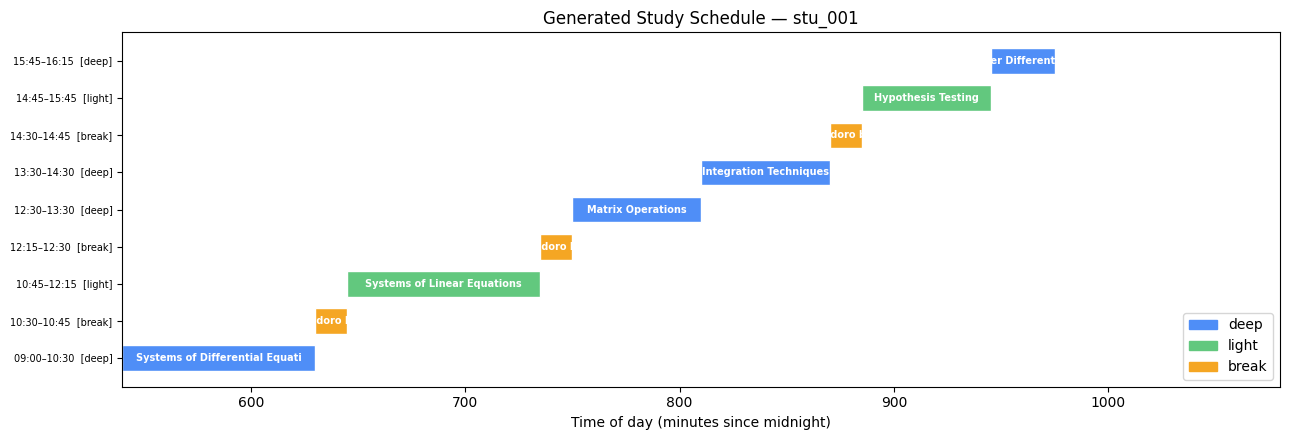

Schedule plot saved.


In [17]:
# Visualise the schedule as a Gantt-style timeline
TYPE_COLORS = {'deep': '#4f8ef7', 'light': '#62c87e', 'break': '#f5a623'}

fig, ax = plt.subplots(figsize=(13, max(3, len(schedule) * 0.5)))

for i, block in enumerate(schedule):
    start_min = int(block['start'][:2]) * 60 + int(block['start'][3:])
    end_min   = int(block['end'][:2])   * 60 + int(block['end'][3:])
    ax.barh(
        i, end_min - start_min, left=start_min,
        color=TYPE_COLORS.get(block['type'], '#aaa'), edgecolor='white', height=0.7
    )
    label_x = start_min + (end_min - start_min) / 2
    ax.text(label_x, i, block['topic'][:30], va='center', ha='center',
            fontsize=7, color='white', fontweight='bold')

ax.set_yticks(range(len(schedule)))
ax.set_yticklabels([f"{b['start']}–{b['end']}  [{b['type']}]" for b in schedule], fontsize=7)
ax.set_xlabel('Time of day (minutes since midnight)')
ax.set_title(f'Generated Study Schedule — {sample_student}')
ax.set_xlim(9 * 60, 18 * 60)

from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=t) for t, c in TYPE_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right')

plt.tight_layout()
plt.savefig(MODELS_DIR / 'study_schedule_sample.png', dpi=120)
plt.show()
print('Schedule plot saved.')

---
## Summary

All Phase 2 artifacts are now trained and validated:

| Artifact | Location | Next step |
|---|---|---|
| `error_classifier.pkl` | `models/` | Copy to `server/ai/models/` — loaded by `error_classifier.py` |
| `label_encoder.pkl` | `models/` | Copy alongside the classifier |
| `shap_explainer.pkl` | `models/` | Loaded at inference time for per-prediction SHAP |
| `topic_stability.csv` | `models/` | Used to seed the Supabase `topic_stability` table |
| EAR formula | This notebook | Ported verbatim into `server/ai/ear_processor.py` |
| TF-IDF retriever | This notebook | Replaced by Azure pgvector in production (`server/ai/rag_pipeline.py`) |
| Schedule generator | This notebook | Ported into `server/ai/study_optimizer.py` |

Run the embedding seed cell (`RUN_EMBEDDING_SEED = True`) once credentials are available to populate the `curriculum_embeddings` Supabase table.